## DLA CODE OF CONDUCT V2.0

This Code of Conduct defines the principles governing ethical, transparent, and responsible use of Large Language Models (LLMs), online resources, and peer collaboration in the Deep Learning Applications laboratories. This version of the Code of Conduct was refined via a brainstorming session with **ChatGPT Version 5.2** and subsequently adapted to reflect the specific requirements and values of the DLA laboratories. In that spirit, this Code itself models the transparency it expects from you.

***Our goal is not to restrict innovation, but to ensure integrity, accountability, and genuine learning.***

### 1. Transparency in the Use of LLMs and AI Tools

The use of LLMs and AI-assisted tools is permitted — *but it must be transparent*.

* **Explicit Disclosure:** Clearly state if and how LLMs (e.g., ChatGPT, Copilot, Claude, etc.) were used. This includes code generation, debugging, data analysis, experiment design, report writing, or conceptual clarification.
* **Description of Contribution:** Briefly describe what the tool contributed and how you modified, verified, or extended its output.
* **Acknowledgment of Limitations:** Recognize that LLM outputs may contain errors, biases, or non-optimal solutions. You are responsible for verifying correctness, appropriateness, and academic integrity.

***Using AI does not reduce your responsibility for the final result.***

### 2. Proper Attribution and Documentation

Deep learning builds on existing work — responsibly.

* **Attribution:** Properly cite all external resources, including: Code snippets, Tutorials, Documentation, Datasets, Pretrained models, Research papers, and AI-generated content.
* **Reproducibility:** Clearly document tools, libraries, model versions, hyperparameters, and experimental setups so that your work can be reproduced.
* **Clarity of Modifications:** If you adapt external code, explicitly indicate what you changed and why.

***Transparency is a sign of scientific maturity — not weakness.***

### 3. Collaboration and Individual Responsibility

Discussion is encouraged. Copying is not.

* **Collaborative Learning:** You are encouraged to discuss concepts, debugging strategies, and approaches with classmates.
* **Individual Submission:** Your submitted solution must reflect your own understanding and implementation.
* **No Direct Sharing of Solutions:** Do not share complete solutions, trained models, or reports. Do not submit another person's work — or AI-generated work — as your own without meaningful engagement and proper disclosure.

***If you cannot explain your submission, it is not your submission.***

### 4. Accountability and Academic Integrity

You are responsible for everything you submit. Failure to comply with these guidelines may result in review by the course examination commission and can lead to disciplinary measures in accordance with university regulations.

***Integrity is part of your training as a machine learning practitioner.***

### 5. The Spirit of This Code of Conduct

This course prepares you to work in a field where:

* Reproducibility matters
* Ethical considerations matter
* Transparency matters
* Responsible AI use matters

***The purpose of this Code of Conduct is not surveillance — it is professional formation.***

### TL;DR

Use AI; Don’t let AI use you; Be transparent; Cite everything; Do your own thinking.

***If you can’t explain it, you probably shouldn’t submit it.***

---
---

## Introduction

In this first laboratory we will see a few ways to exploit and adapt pre-trained models to solve new problems. We will start first by downloading and instantiating a new dataset and establishing a stable and reproducible baseline model based on a pre-trained CNN.

---

## Exercise 1 (Warmup): Exploratory Data Analysis and a Stable Baseline

For this laboratory we will work with [The German Traffic Sign Detection Benchmark](https://benchmark.ini.rub.de/) [1]. We will begin, not with *detection*, but with a simpler traffic sign *classification* problem. This has two advantages: (1) the images are *smaller* than in the detection benchmark; and (2) a wrapper for the GTSRB dataset is conveniently included in the `torchvision` library.  

[1] Houben S, Stallkamp J, Salmen J, Schlipsing M, Igel C. Detection of traffic signs in real-world images: The German Traffic Sign Detection Benchmark. In The 2013 International Joint Conference on Neural Networks (IJCNN), 2013.

### Exercise 1.1: Exploratory Data Analysis

A good best practice to adopt in all experimental deep learning projects is thorough *exploratory data analysis*. In this exercise you should instantiate the GTSRB Dataset, inspect some images, and do some statistical analysis of the distribution of data (and metadata). A goal here is to keep an eye out for anything that might be problematic in what is to come.



In [15]:
# Standard imports and aliases.
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.transforms.v2 as T     # Use transforms v2; much more efficient.
from torchvision.datasets import GTSRB
import random as rnd

# Your code here.
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Using device: {device}')
seed = 42
_ = torch.manual_seed(seed)

Using device: mps


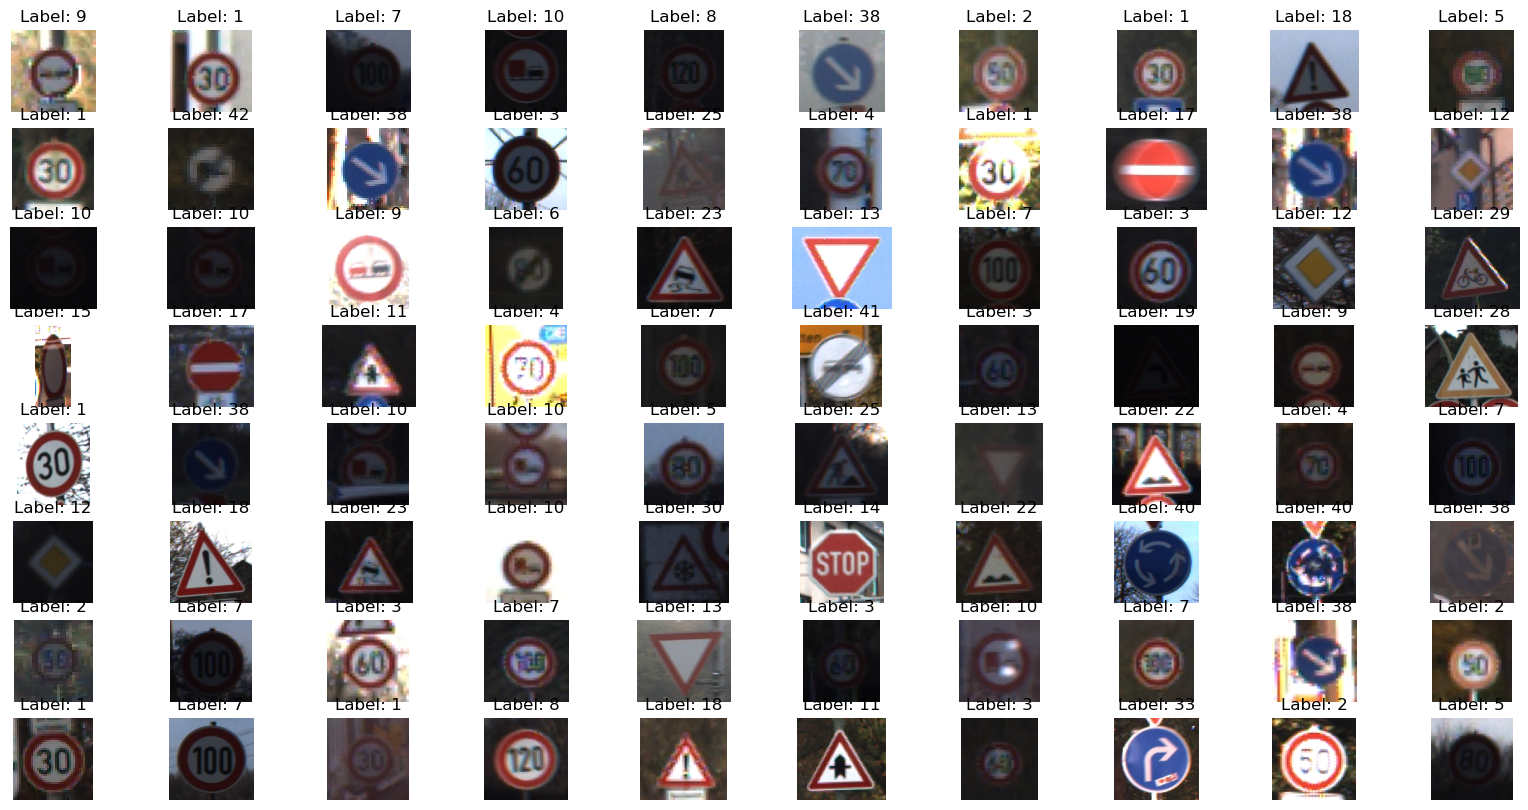

In [16]:
DsTrain = GTSRB(root='data', split='train', download=True)
DsTest = GTSRB(root='data', split='test', download=True)


RawSamples = 8
ColSamples = 10
DsSample = [DsTrain[i] for i in rnd.sample(range(len(DsTrain)), RawSamples*ColSamples)]

fig, axes = plt.subplots(RawSamples, ColSamples, figsize=(20, 10))
for i in range(RawSamples):
    for j in range(ColSamples):
        img, label = DsSample[i*ColSamples+j]
        
        axes[i,j].imshow(img)
        axes[i,j].set_title(f'Label: {label}')
        axes[i,j].axis('off')

Dal campione delle immagini selto in modo casuale con la funzione `rnd.sample` possiamo osservar come le **_immagini differiscano_** per:
- **Esposizione**
- **Risoluzione**
- **Luminosità**
- **Angolo della fotografia**

questo è dunque un dataset abbastanza _eterogeneo_ con immagini di diversa tipologia e con foto mai prese nelle stesse codizioni di scatto.

In [18]:
import pandas as pd

GeomProp = pd.DataFrame(columns=['Width', 'Height', 'Aspect Ratio', 'Label'])
for i in range(DsTrain.__len__()):
    img, label = DsTrain[i]
    width, height = img.size
    aspect_ratio = width / height
    GeomProp.loc[i] = [width, height, aspect_ratio, label]
    

              Width        Height  Aspect Ratio         Label
count  26640.000000  26640.000000  26640.000000  26640.000000
mean      50.933784     50.365128      1.008718     15.887387
std       24.373418     23.161523      0.072100     12.044099
min       25.000000     25.000000      0.368132      0.000000
25%       35.000000     35.000000      0.972222      5.000000
50%       43.000000     43.000000      1.000000     12.000000
75%       58.000000     58.000000      1.044444     25.000000
max      243.000000    225.000000      1.417808     42.000000


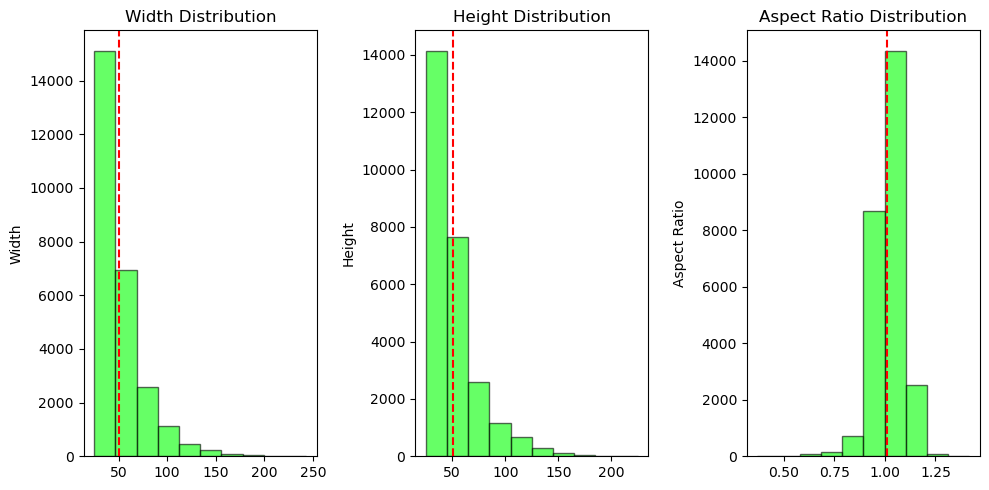

In [19]:
print(GeomProp.describe())

fig, axis = plt.subplots(1,3, figsize=(10, 5))
for i, prop in enumerate(['Width', 'Height', 'Aspect Ratio']):
    axis[i].hist(GeomProp[prop], bins=10, color='lime', alpha=0.6, edgecolor='black')
    axis[i].set_ylabel(prop)
    axis[i].axvline(GeomProp[prop].mean(), color='red', linestyle='dashed', linewidth=1.5, label='Mean')
    axis[i].set_title(f'{prop} Distribution')     
plt.tight_layout()

Come si può vedere anche dagli istogrammi delle _proprietà geometriche_ le immagini non hanno tutte lo stesso **Aspect Ratio**, ovvero il rapporto $\frac{Width}{Height}$; dunque non tutte le immagini hanno le stesse dimensioni. Infatti la _media_ delle immagini risulta essere centrata intorno a 50 sia per **Altezza** che **Larghezza**; tuttavia la _moda_ risulta essere minore della _media_, possiamo affermare con una certa confidenza che sono presenti degli **_Outliners_** nelle distribuzioni delle proprietà geometriche delle immagini.

Class with most samples: [2.0, 1.0] (1500 samples)
Class with least samples: [37.0, 19.0, 0.0] (150 samples)


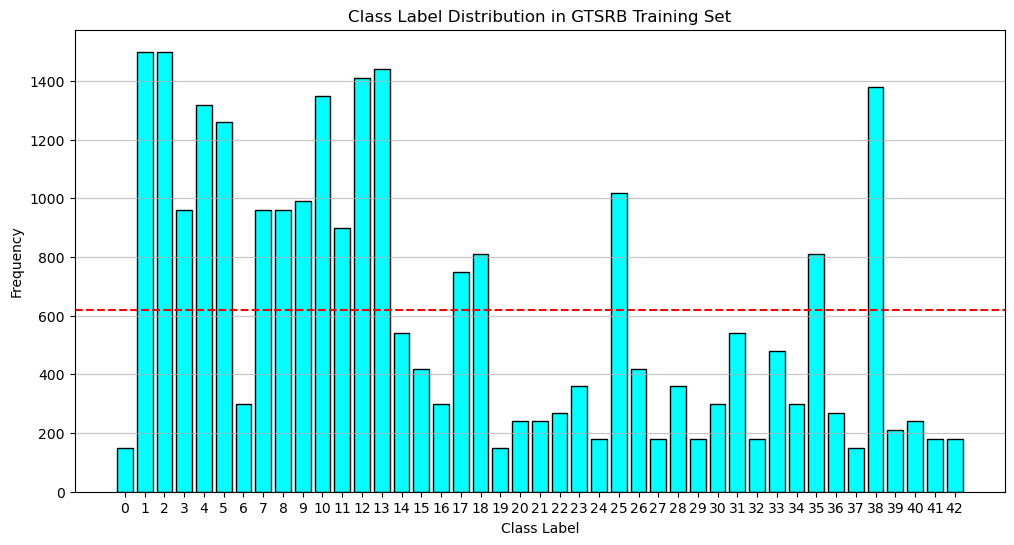

In [20]:
ClassesWithMostSamples = [label for label, count in GeomProp['Label'].value_counts().items() if count == GeomProp['Label'].value_counts().max()]
print(f'Class with most samples: {ClassesWithMostSamples} ({GeomProp["Label"].value_counts().max()} samples)')
ClassWithLeastSamples = [label for label, count in GeomProp['Label'].value_counts().items() if count == GeomProp['Label'].value_counts().min()]
print(f'Class with least samples: {ClassWithLeastSamples} ({GeomProp["Label"].value_counts().min()} samples)')


LabelDistribution = GeomProp['Label'].value_counts().sort_index()
LabelMean = LabelDistribution.mean()
plt.figure(figsize=(12, 6))
plt.bar(LabelDistribution.index, LabelDistribution.values, color='cyan', edgecolor='black') # type: ignore
plt.axhline(LabelMean, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {LabelMean:.2f}')
plt.xlabel('Class Label')
plt.ylabel('Frequency')
plt.title('Class Label Distribution in GTSRB Training Set')
plt.xticks(LabelDistribution.index)
plt.grid(axis='y', alpha=0.75)

Come possiamo vedere dalla distribuzione per classe degli esempi il dataset è **_sbilanciato_**, abbiamo infatti numerosi esempi in alcune classi, ad esempio le _classi 1 e 2_ sono quelle con più campioni al loro interno; le _classi 0, 19, 37_ sono invece quella meno rappresentate.

**Eviterò** l'utilizzo tecniche di _data augmentation_ poiché il dataset sembra abbastanza fornito di immagini con differenti angolazioni dei cartelli, esposizioni e diversi livelli di luminosità.

In [6]:
transform = T.Compose([
    T.Resize(70),
    T.CenterCrop(64),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

DsTrain.transform = transform
DsTest.transform = transform

### Analysis

Deep Learning is very much an *experimental* discipline. Experiments are *nothing* without analysis and interpretation. Be sure to **always** stop and analyze the results of preliminary explorations. Note anything significant and -- importantly -- anything that is going to be relevant for what comes next.

So... In this Markdown cell you should collect and report (using, for the love of God, the *rich markup capabilities of Markdown*) any relevant findings you have made before proceding.

**Important Warning**: This is the **one and only** time I will remind you of the need to provide *analysis* and interpretation of your experimental methodology and results. The responsibility is *yours* to include it elsewhere.


---
### Exercise 1.2: A Stable and Reproducible Baseline

In this exercise you should implement code to use a pretrained network as a *feature extractor* that, instead of *classifying* images in input, should return the *feature representation* from the last layer of the pretrained model before the classifier. These features, extracted from the train set, should be used to train a *classical* model for classification (e.g. an SVM, a Nearest Neighbor, or a Linear Discriminant classifier from Scikit-learn). Evaluate the performance of this baseline model on the features extracted from the test set.

In [7]:
# Your code here.
from torchvision.models import get_model
import torch.nn as nn
from tqdm.notebook import tqdm

model = get_model('resnet18', weights = 'DEFAULT')
model.fc = nn.Identity()
model = model.to(device)

print(f'Model architecture:\n{model}')


Model architecture:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): R

In [8]:
def FeatureExtraction(dataset, model, device= 'cpu'):
     OutputFeatures = []
     ClassesFeatures = []
     for (img, label) in tqdm(dataset):
          img = img.to(device, non_blocking=True)
          with torch.no_grad():
               OutputFeatures.append(model(img))
          ClassesFeatures.append(label)
     OutputFeatures_Test = torch.vstack(OutputFeatures).cpu()
     ClassesFeatures_Test = torch.concat(ClassesFeatures)

     print(f'Output features shape (test): {OutputFeatures_Test.shape}')
     print(f'Classes shape (test): {ClassesFeatures_Test.shape}')

     return OutputFeatures_Test, ClassesFeatures_Test

In [9]:
from torch.utils.data import DataLoader
BatchSize = 1024
DlTrain = DataLoader(DsTrain, batch_size=BatchSize, shuffle=True, num_workers=4, prefetch_factor=3)
DlTest = DataLoader(DsTest, batch_size=BatchSize, shuffle=False, num_workers=4, prefetch_factor=3)

In [10]:
TrainFeatures, TrainLabels = FeatureExtraction(DlTrain, model, device)

  0%|          | 0/27 [00:00<?, ?it/s]

Output features shape (test): torch.Size([26640, 512])
Classes shape (test): torch.Size([26640])


In [11]:
TestFeatures, TestLabels = FeatureExtraction(DlTest, model, device)

  0%|          | 0/13 [00:00<?, ?it/s]

Output features shape (test): torch.Size([12630, 512])
Classes shape (test): torch.Size([12630])


In [12]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

def SvmClassification(svm, TrainFeatures, TrainLabels, TestFeatures, TestLabels):
     svm.fit(TrainFeatures, TrainLabels)
     Predictions = svm.predict(TestFeatures)

     print(classification_report(TestLabels, Predictions))

In [13]:
svm = SVC(kernel='linear')
SvmClassification(svm, TrainFeatures, TrainLabels, TestFeatures, TestLabels)


              precision    recall  f1-score   support

           0       0.22      0.18      0.20        60
           1       0.40      0.53      0.45       720
           2       0.36      0.41      0.39       750
           3       0.23      0.28      0.25       450
           4       0.43      0.39      0.41       660
           5       0.37      0.30      0.33       630
           6       0.77      0.75      0.76       150
           7       0.47      0.50      0.49       450
           8       0.32      0.29      0.31       450
           9       0.60      0.49      0.54       480
          10       0.70      0.72      0.71       660
          11       0.38      0.50      0.43       420
          12       0.80      0.86      0.83       690
          13       0.84      0.90      0.87       720
          14       0.87      0.69      0.77       270
          15       0.85      0.82      0.84       210
          16       0.83      0.80      0.81       150
          17       0.87    

Come possiamo vedere la SVM **non riesce ad apprendere correttamente** la superficiee di decisione per separare in modo ottimale gli esempi sulla base delle _features estratte dai layer convoluzionali_, l'accuratezza del modello si ferma infatti al **50 %**; si potrebbero migliorare le prestazioni andando a considerare dei **_kernel differenti_** da quello lineare.


---
### Exercise 1.3: A Fine-tuning Baseline

In this exercise you should try to *improve* on the stable baseline given by the feature extraction + SVM (or whatever) classifier you produced in the previous lecture. To do this, you should *fine-tune* the ResNet-18 (or whatever model you chose) to solve the new classification task.

To do this, you could proceed by:
1. Loading the ResNet-18 (or whatever) model and replacing the final FC layer (the classifier) with a *new* classifier. This could be a single Linear layer, or could be an MLP.
2. Training the resulting model on the GTSRB dataset for a few epochs.
3. Evaluating the resulting performance.

Some things you should probably consider (especially thinking about the *next* exercise):
+ You should be monitoring not only the loss on the training set, but also a *validation* loss on an *independent* validation set. Split the training set into two datasets: one with, say, 80% of the original training samples, and another with the remaining 20%. You can use this smaller set to monitor performance and check for *overfitting*.
+ Maybe the best strategy is to not fine-tune *all* layers, but only the last few. Think about *selectively* fine-tuning layers of the network.
+ Maybe a *single* linear layer isn't the best option for the classifier. Think about using an MLP instead.

In [14]:
# Your code here.
from torchvision.models import get_model
import torch.nn as nn
from tqdm.notebook import tqdm

model = get_model('resnet18', weights = 'DEFAULT')
for param in model.parameters():
    param.requires_grad = False # Durante l'addestramento i pesi dei layer convoluzionali non verranno aggiornati, mantenendo le feature già apprese.

mlp = nn.Sequential(
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 43)
)

model.fc = mlp

model = model.to(device)

In [15]:
from sklearn.metrics import accuracy_score, classification_report
import copy

def TrainEpoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for data, labels in tqdm(dataloader, desc="Training"):
        data, labels = data.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * data.size(0)
        
    return running_loss / len(dataloader.dataset)

def Evaluate(model, dataloader, device, criterion = None):
    model.eval()
    predictions = []
    gts = []
    losses = []
    
    with torch.no_grad():
        for data, labels in tqdm(dataloader, desc="Evaluating"):
            data = data.to(device, non_blocking=True) # non_blocking=True permette di sovrapporre il trasferimento dei dati con l'esecuzione del modello, migliorando le prestazioni.
            labels_device = labels.to(device, non_blocking=True)
            
            outputs = model(data)
            
            if criterion is not None:
                loss = criterion(outputs, labels_device)
                losses.append(loss.item())
            
            predicted = torch.argmax(outputs, 1)
            
            # Raccolta dati
            predictions.append(predicted.cpu().numpy())
            gts.append(labels.numpy())
            
    all_gts = np.hstack(gts)
    all_preds = np.hstack(predictions)
    
    return (
        accuracy_score(all_gts, all_preds), 
        classification_report(all_gts, all_preds, zero_division=0), 
        losses
    )

def fit(model, train_loader, val_loader, criterion, optimizer, device, epochs, patience=5, tolerance=1e-3):
    patience_counter = 0
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    
    history = {'train_loss': [], 'val_loss': [], 'accuracy': []}

    for epoch in tqdm(range(epochs), desc="Epochs"):
        train_loss = TrainEpoch(model, train_loader, criterion, optimizer, device)
        
        accuracy, _, val_losses = Evaluate(model, val_loader, device, criterion)
        val_loss = np.mean(val_losses)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['accuracy'].append(accuracy)

        print(f"Epoch {epoch+1}/{epochs} -> Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if val_loss + tolerance < best_val_loss:
            print(f"(!) Nuovo miglior modello trovato (Val Loss diminuita: {best_val_loss:.4f} --> {val_loss:.4f})")
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            print(f"Val Loss non migliorata. Patience Counter: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print("Early stopping attivato. Interruzione dell'addestramento.")
                break


    model.load_state_dict(best_model_wts)
    return model, history

La **running loss** viene utilizzata per avere un andamento medio della loss nell'epoca di addestramento con tutti i dati predetti e confrontati.

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Training:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 1/10 -> Train Loss: 3.0210 | Val Loss: 2.2050
(!) Nuovo miglior modello trovato (Val Loss diminuita: inf --> 2.2050)


Training:   0%|          | 0/21 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 9/10 -> Train Loss: 0.6927 | Val Loss: 0.8191
(!) Nuovo miglior modello trovato (Val Loss diminuita: 0.8442 --> 0.8191)


Training:   0%|          | 0/21 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 10/10 -> Train Loss: 0.6467 | Val Loss: 0.7781
(!) Nuovo miglior modello trovato (Val Loss diminuita: 0.8191 --> 0.7781)
Final Train Loss: 0.6467 | Final Val Loss: 0.7781
Final Val Accuracy: 0.7545


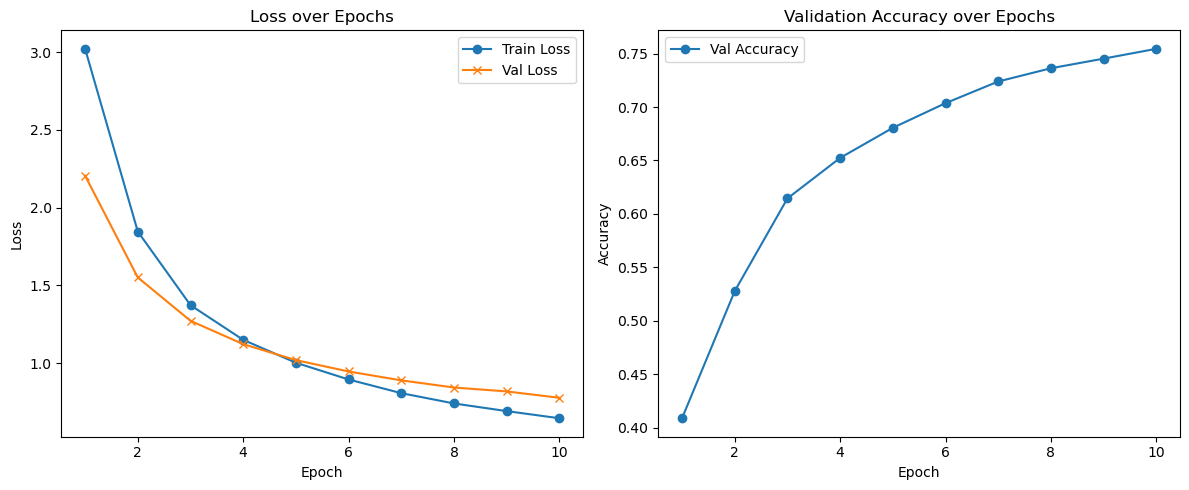

In [16]:
epochs = 10
lr = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
train, val = torch.utils.data.random_split(DsTrain, [int(0.8*len(DsTrain)), int(0.2*len(DsTrain))])
DlTrain = DataLoader(train, batch_size=BatchSize, shuffle=True)
DlVal = DataLoader(val, batch_size=BatchSize, shuffle=False)

model, history = fit(model, DlTrain, DlVal, nn.CrossEntropyLoss(), optimizer, device, epochs)
train_losses = history['train_loss']
val_losses = history['val_loss']
accuracies = history['accuracy']

print(f"Final Train Loss: {train_losses[-1]:.4f} | Final Val Loss: {val_losses[-1]:.4f}")
print(f"Final Val Accuracy: {accuracies[-1]:.4f}")


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, marker='o', label='Train Loss')
plt.plot(range(1, epochs+1), val_losses, marker='x', label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), accuracies, marker='o', label='Val Accuracy')
plt.title('Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()

La _**accuracy**_ in questo caso è calcolata sul _valuation-set_, il report successivo fa riferimento al _test-set_.

In [17]:
_, report, _ = Evaluate(model, DlTest, device)

print('Classification Report:')
print(report)

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

Classification Report:
              precision    recall  f1-score   support

           0       0.11      0.05      0.07        60
           1       0.49      0.52      0.50       720
           2       0.38      0.42      0.40       750
           3       0.24      0.32      0.28       450
           4       0.46      0.45      0.45       660
           5       0.38      0.34      0.36       630
           6       0.63      0.70      0.66       150
           7       0.54      0.52      0.53       450
           8       0.25      0.30      0.27       450
           9       0.61      0.46      0.53       480
          10       0.65      0.79      0.71       660
          11       0.42      0.35      0.38       420
          12       0.85      0.86      0.85       690
          13       0.87      0.90      0.88       720
          14       0.77      0.69      0.73       270
          15       0.94      0.79      0.86       210
          16       0.93      0.74      0.82       150
    

L'integrazione di un MLP per la classificazione **non ha prodotto miglioramenti sostanziali** nella qualità del modello. L'accuratezza rilevata è infatti del **51%**, un valore identico al **51%** ottenuto dalla SVM addestrata sull'output dei layer convoluzionali.

Dall'analisi dettagliata delle metriche emergono tuttavia differenze comportamentali degne di nota:

- **Classi Minoritarie**: Nel modello con MLP si osserva un peggioramento di precision, recall e f1-score nella **classe 0** e, più in generale, in tutte le classi caratterizzate da un esiguo numero di campioni. In questi scenari, la SVM dimostra una maggiore robustezza.

- **Classi Maggioritarie**: Nelle classi con un numero elevato di rappresentanti, il layer lineare mostra un incremento di f1-score e precision, a fronte però di un calo nella recall.

_Considerazioni sulle Medie_

Il confronto tra le medie macro (semplici) e weighted (pesate) conferma la scarsa divergenza tra i due approcci, evidenziando però una diversa specializzazione:

1. **_Media Macro_**: La **SVM** mantiene un leggero vantaggio, confermando una migliore capacità di gestione delle classi meno rappresentate.

2. **_Media Pesata_**: Il **MLP** prevale leggermente, segno di una migliore performance sulle classi numericamente dominanti.

In conclusione, mentre la SVM sacrifica parte della precisione sulle classi numerose per garantire una classificazione più equilibrata, il MLP tende a ottimizzare il risultato sulle classi principali, faticando tuttavia a generalizzare correttamente in presenza di pochi campioni.

---
---
## Exercise 2: Pipeline Consolidation

Consolidate your implementation. When building applications based asd on Deep Learning, you will inevitably need to run many, many experiments. So, it is *always* a good idea to engineer a reproducible pipeline that allows you to run (and re-run) experiments with different hyperparameters. In this exercise you should do exactly this: engineer a deep learning pipeline that encapsulates (at least) training and evaluation so that you can easily and reproducibly run multiple experiments and compare the results.

Some things to think about when engineering this pipeline:
- **Model and Loss (and maybe Optimizer) Abstraction**: An important variable in training deep models is the model (obviously), the loss (somewhat less obvious), and the optimizer (less obvious) used during training. Your pipeline should probably be able to adapt to these changing configurations.
- **Configuration management**: Instead of global variables specializing each cell, thread a configuration object through your code (or use a singleton). If you are planning to use an IDE and not this notebook for the lab, you might consider using a configuration management library like [OmegaConf](https://omegaconf.readthedocs.io/en/2.3_branch/) which will help instrument your code so that you can pass configuration overrides via command line arguments.
- **Logging**: You will invariably need to run and compare multiple experiments. Instrument your code for monitoring training. Good options are [Tensorboard](https://docs.pytorch.org/tutorials/recipes/recipes/tensorboard_with_pytorch.html) or [Weights and Biases (WandB)](https://wandb.ai/site/). My PhD students seem to overwhelmingly prefer Weights and Biases. The configuration parameters should be used to facilitate distinguishing and comparing multiple runs with multiple hyperparameters.

In [ ]:
# Your code here.
from Trainer import TrainerFactory as MT
from Experiment import experiment
from Lab_1.DataModule import data_module
from torchvision.models import get_model
import torch.nn as nn
import torch

In [21]:
model = get_model('resnet18', weights = 'DEFAULT')
model.fc = mlp
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
epochs = 10

trainer = MT.get_trainer('multiclass',model, optimizer, nn.CrossEntropyLoss(), device)
data_handler = data_module(DsTrain, DsTest, batch_size=512)
exp = experiment(trainer, data_handler, name="ResNet18_Experiment")

In [22]:
exp.run(epochs, early_stopping=True, patience=3)

Starting experiment: logs/ResNet18_Experiment_20260504_120704
Data split into 21312 training and 5328 validation samples
Training model...

--- Epoch 1/10 ---


Train Loss: 0.3822 | Val Loss: 0.0634 | Accuracy: 0.9820
(!) Nuovo miglior modello (Val Loss diminuita: inf --> 0.0634)

--- Epoch 2/10 ---


Train Loss: 0.0134 | Val Loss: 0.0157 | Accuracy: 0.9949
(!) Nuovo miglior modello (Val Loss diminuita: 0.0634 --> 0.0157)

--- Epoch 3/10 ---


Train Loss: 0.0089 | Val Loss: 0.0348 | Accuracy: 0.9906
Val Loss non migliorata. Patience: 1/3 (Tol: 0.001)

--- Epoch 4/10 ---


Train Loss: 0.0145 | Val Loss: 0.0553 | Accuracy: 0.9840
Val Loss non migliorata. Patience: 2/3 (Tol: 0.001)

--- Epoch 5/10 ---


Train Loss: 0.0169 | Val Loss: 0.1084 | Accuracy: 0.9696
Val Loss non migliorata. Patience: 3/3 (Tol: 0.001)
Early stopping attivato. Interruzione dell'addestramento.

Caricamento dei pesi del modello migliore...
Evaluating...


Log salvati in: logs/ResNet18_Experiment_20260504_120704/metrics.json
Experiment completed. Results in: logs/ResNet18_Experiment_20260504_120704


Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.83      0.79        60
           1       0.96      0.96      0.96       720
           2       0.91      0.97      0.94       750
           3       0.98      0.92      0.95       450
           4       0.98      0.96      0.97       660
           5       0.97      0.92      0.94       630
           6       0.99      0.99      0.99       150
           7       0.89      0.99      0.94       450
           8       0.90      0.92      0.91       450
           9       0.99      0.96      0.97       480
          10       1.00      1.00      1.00       660
          11       0.94      0.90      0.92       420
          12       1.00      0.99      0.99       690
          13       1.00      0.99      1.00       720
          14      

La pipeline funziona in questo modo esistono 4 classi:
- **Model Trainer**: incapsula tutto quello che è necessario per addestrare e valutare il modello, dunque c'è un metodo _modelTrainer_ in cui viene implementato un passaggio completo sul dataset ed un metodo _modelEvaluate_ per valutare le performance del modello dopo l'addestramento.
- **Experiment**: si occupa di impostare l'ambiente con la gestione del dataloader e del logging generando le cartelle per salvare le statistiche ed i grafici costruiti nell'esperimento, inoltre lancia l'esperimento vero e proprio misurando la _loss_ e iterando sul dataset passando i batch di addestramento alla classe trainer.
- **Logger**: è una classe nascosta che si occupa del logging e della presentazione dei risultati dell'esperimento, solo la classe esperimento può accedervi.
- **Data handler**: Si occupa della preparazione dei dati e dalla costruzione dei dataloader.

I risultati sono stati ottenuti considerando una rete addestrata da zero sul dataset in esame, per questo non verrà messa a confronto con nessuno degli altri esperimenti rendendola così solo un esempio per mostrare l'utilizzo della pipeline creata.


---
---
## Exercise 3: Choose your Own Adventure

As promised, you should choose **one** of the following exercises to work. Well, at *least* one. If you want to do them all, that is also OK! 

---
### Exercise 3.1 (Easy): Improving Fine-tuning Performance

In this exercise you are asked to iterate on the fine-tuning experiment performed in Exercise 1.3 in order to squeeze the best performance possible out of the model.

What can we do:
- Use a more powerful model?
- More aggressive data augmentation?
- Selective layer training?
- Something else?

**Why choose this exercise?** To hone your skills at incrementally improving fined-tuned model performance via a sequence of (carefully monitored) experiments.

In [ ]:
# Your code here.


---
### Exercise 3.2: Retrieval as Training-free Classification (a bit harder)

In this exercise you will treat the problem of classifying road signs as a type of retrieval problem. By doing so, will will avoid the need to perform extensive fine-tuning of our model and will instead count of the good *representations* provided by massively pretrained models.

How, you ask? In this exercise you should treat the training set as a *gallery* of indexed image descriptors and the test set as a set of *query* descriptors. You could proceed in this way:

1. **Implement** a generic *feature extraction* function that, given a model and a dataloader, will extract the feature representations of all images in the dataloader. You should make this function generic because you will of course want to try *multiple* pretrained backbones in order to pick the best one.
2. **Implement** a function to *query* the gallery using all extracted from the test set. The results of this should be a *ranking* of all gallery images in terms of similarity with each test image. You should think carefully about how to compute this *similarity* score and how to compute it efficiently.
3. **Evaluate** the retrieval performance on each of the 43 classes in the GTSRB dataset using the similarity scores. This could be done using precision recall curves, average precision/recall, or other metrics.

Wait, this isn't a classifier... Well, no. But, if you use the above *pipeline* to select the best feature extraction pipeline, you can then implement a **Nearest-Mean Classifier (NMC)**: compute the *mean* feature representation of all training images for each class and *classify* test images based on which mean is **nearest** to it.

**Why choose this exercise?** To learn how to make the most out of pretrained feature extraction backbones, how to evaluate different types of learning systems (retrieval in this case), and to familiarize yourself with similarity-based classification which is extensively used in multimodal models like CLIP.

In [ ]:
import torch
import numpy as np
from torchvision.models import get_model
import torch.nn as nn
import torch.nn.functional as F
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader
from torchvision.datasets import GTSRB
import torchvision.transforms.v2 as T
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, classification_report

torch.manual_seed(42)

device = 'mps' if torch.backends.mps.is_available() else 'cpu'
#list_models()


In [10]:
# Your code here.
transform = T.Compose([
    T.Resize(70, antialias=True),
    T.CenterCrop((64,64)),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

ds_train = GTSRB(root='data', split='train', download=True, transform=transform)
ds_test = GTSRB(root='data', split='test', download=True, transform=transform)

dl_train = DataLoader(ds_train, batch_size=512, shuffle=True, num_workers=4, prefetch_factor=4, persistent_workers=True)
print(f'Training DataLoader created with {len(dl_train.dataset)} samples and batch size of {dl_train.batch_size}.')
dl_test = DataLoader(ds_test, batch_size=512, shuffle=False, num_workers=4, prefetch_factor=4, persistent_workers=True)
print(f'Test DataLoader created with {len(dl_test.dataset)} samples and batch size of {dl_test.batch_size}.')

Training DataLoader created with 26640 samples and batch size of 512.
Test DataLoader created with 12630 samples and batch size of 512.


In [11]:
class NearestNeighborClassifier:
    def __init__(self, backbone, device):
        self.backbone = backbone
        self.device = device
        self.gallery = None

    def feature_extraction(self, dataloader):
     self.backbone.eval()
     features = []
     labels = []
     
     with torch.no_grad():
          for data, label in tqdm(dataloader, desc="Extracting Features"):
               data = data.to(self.device, non_blocking=True)
               output = self.backbone(data)
               features.append(output.cpu())
               labels.append(label.cpu())
     
     return torch.cat(features), torch.cat(labels)
    
    def gallery_creator (self, features, labels, num_classes=43, samples_per_class=5):
     class_samples = {i: [] for i in range(num_classes)}
     gallery = torch.zeros((num_classes, features.shape[1]))  # Inizializza la galleria con zeri
     print(f'Initialized gallery with shape: {gallery.shape}')

     for feature, label in zip(features, labels):
          class_samples[int(label)].append(feature)

     #ordina le chiavi in base al numero della label e calcola la media dei campioni per ogni classe
     class_samples_ord = {k: class_samples[k] for k in sorted(class_samples.keys())}
     
     for class_label, samples in class_samples_ord.items():
          gallery[class_label] = torch.mean(torch.stack(samples), dim=0)  # Calcola la media e assegna alla galleria
          
     print(f'Gallery created with {len(gallery)} classes and {gallery.shape[0]} features per class.')
     return gallery
    
    def fit(self, dl_train):
     features, labels = self.feature_extraction(dl_train)
     self.gallery = self.gallery_creator(features, labels)

    def classify(self, query_feature, gallery, temperature=20):
        
        def cosine_similarity(a, b):
          a_norm = a / torch.norm(a, dim=1, keepdim=True)
          b_norm = b / torch.norm(b, dim=1, keepdim=True)
          logits = (a_norm @ b_norm.T)*temperature  # Calcola la similarità coseno
          return F.softmax(logits, dim=1)  # Calcola la similarità coseno e normalizza con softmax per ottenere probabilità
        
        similarities = cosine_similarity(query_feature, gallery) 
        predicted_label = torch.argmax(similarities, dim=1)
        return predicted_label, similarities
    
    def evaluate(self, dl_test):
     assert self.gallery is not None, "Gallery non creata. Esegui fit() prima di evaluate()."
     self.backbone.eval()
     predictions = []
     similarities = []
     test_labels = []
     
     with torch.no_grad():
          for data, label in tqdm(dl_test, desc="Evaluating"):
               data = data.to(self.device, non_blocking=True)
               output = self.backbone(data)
               pred_label, sim = self.classify(output, self.gallery.to(self.device))
               predictions.append(pred_label.cpu())
               similarities.append(sim.cpu())
               test_labels.append(label.cpu())
     return torch.cat(predictions), torch.cat(similarities), torch.cat(test_labels)

In [12]:
def plot_multiclass_curves(Y_true_bin, Y_scores, class_to_plot=0):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- CURVA ROC ---
    fpr, tpr, _ = roc_curve(Y_true_bin[:, class_to_plot], Y_scores[:, class_to_plot])
    roc_auc = auc(fpr, tpr)
    
    ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title(f'ROC Curve per la Classe {class_to_plot}')
    ax1.legend(loc="lower right")
    
    # --- CURVA PRECISION-RECALL ---
    precision, recall, _ = precision_recall_curve(Y_true_bin[:, class_to_plot], Y_scores[:, class_to_plot])
    ap = average_precision_score(Y_true_bin[:, class_to_plot], Y_scores[:, class_to_plot])
    
    ax2.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AP = {ap:.2f})')
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title(f'Precision-Recall Curve per la Classe {class_to_plot}')
    ax2.legend(loc="lower left")
    
    plt.show()


--- Evaluating resnext50_32x4d ---


Extracting Features:   0%|          | 0/53 [00:00<?, ?it/s]

Initialized gallery with shape: torch.Size([43, 2048])
Gallery created with 43 classes and 43 features per class.


Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

Classification Report for resnext50_32x4d:
              precision    recall  f1-score   support

           0       0.01      0.08      0.03        60
           1       0.38      0.31      0.34       720
           2       0.39      0.35      0.37       750
           3       0.14      0.03      0.05       450
           4       0.50      0.26      0.34       660
           5       0.31      0.30      0.30       630
           6       0.43      0.98      0.60       150
           7       0.28      0.25      0.26       450
           8       0.14      0.15      0.14       450
           9       0.54      0.51      0.53       480
          10       0.50      0.43      0.46       660
          11       0.64      0.16      0.26       420
          12       0.91      0.79      0.85       690
          13       0.92      0.79      0.85       720
          14       0.85      0.76      0.81       270
          15       0.46      0.74      0.56       210
          16       0.46      0.73     

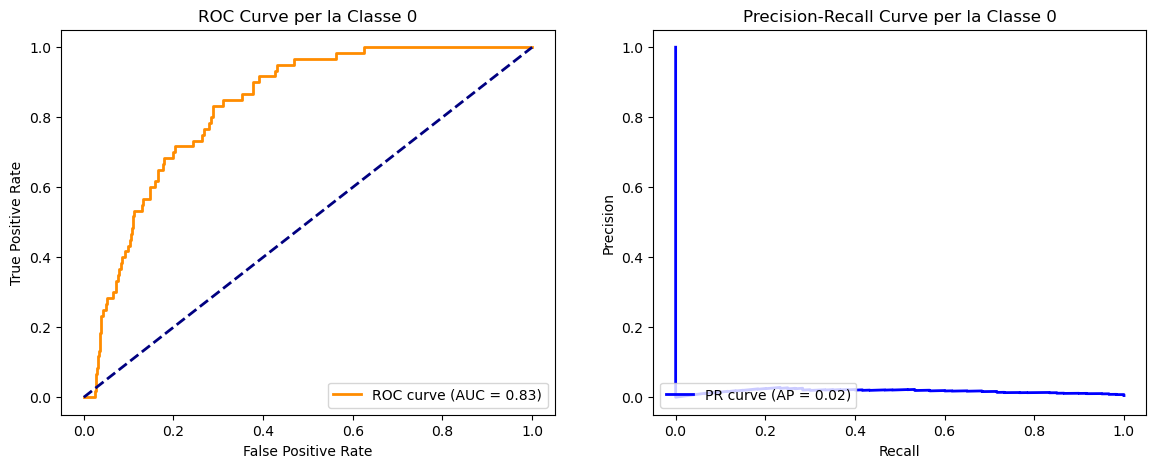

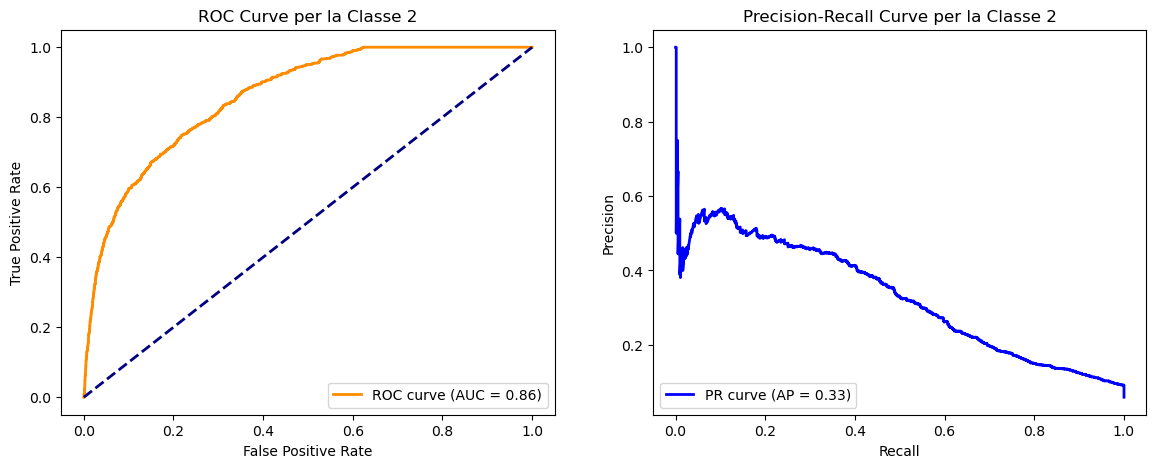

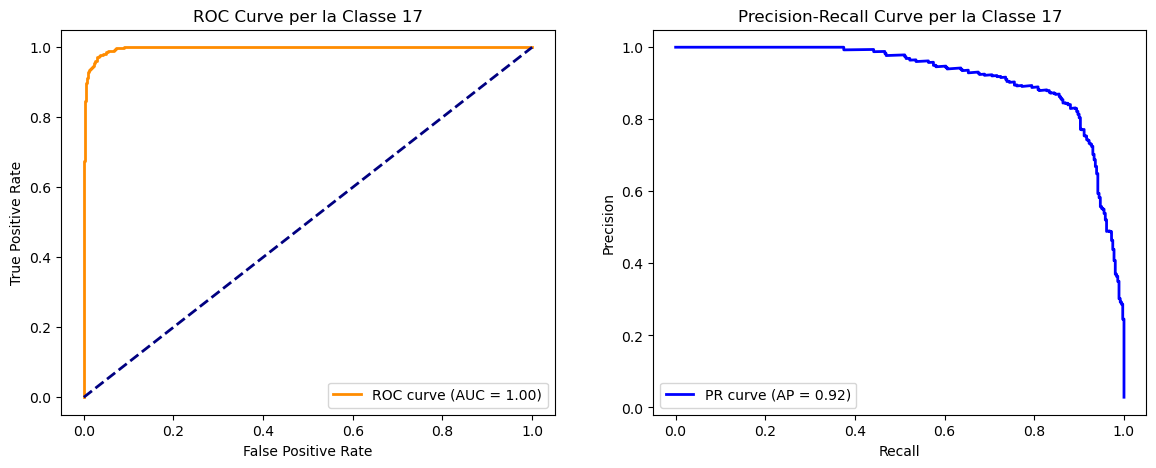


--- Evaluating DenseNet121 ---


Extracting Features:   0%|          | 0/53 [00:00<?, ?it/s]

Initialized gallery with shape: torch.Size([43, 1000])
Gallery created with 43 classes and 43 features per class.


Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

Classification Report for DenseNet121:
              precision    recall  f1-score   support

           0       0.01      0.08      0.02        60
           1       0.50      0.29      0.37       720
           2       0.39      0.31      0.35       750
           3       0.13      0.11      0.12       450
           4       0.36      0.32      0.34       660
           5       0.58      0.14      0.22       630
           6       0.39      0.89      0.54       150
           7       0.29      0.37      0.33       450
           8       0.12      0.17      0.14       450
           9       0.53      0.32      0.40       480
          10       0.45      0.41      0.43       660
          11       0.37      0.28      0.32       420
          12       0.82      0.84      0.83       690
          13       0.97      0.78      0.87       720
          14       0.80      0.82      0.81       270
          15       0.71      0.84      0.77       210
          16       0.49      0.61      0.5

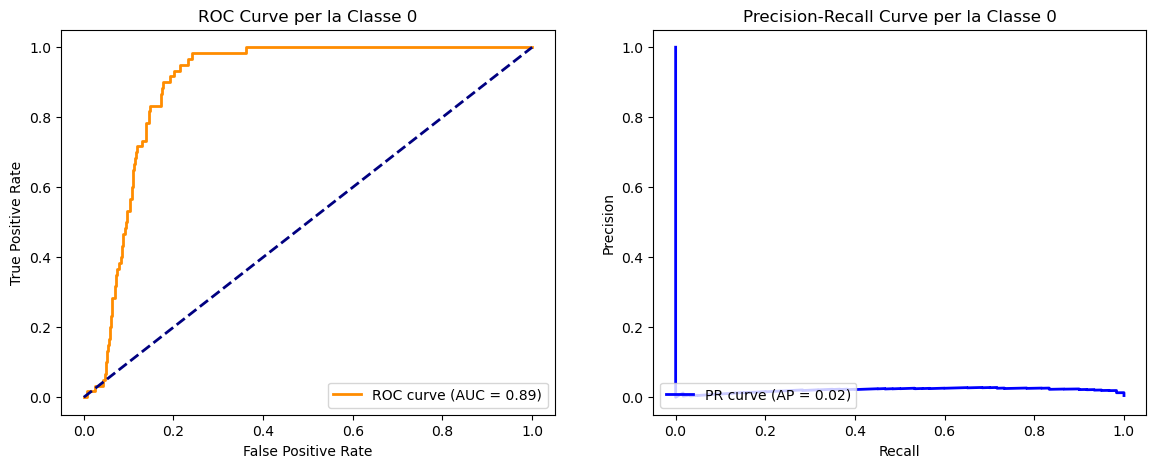

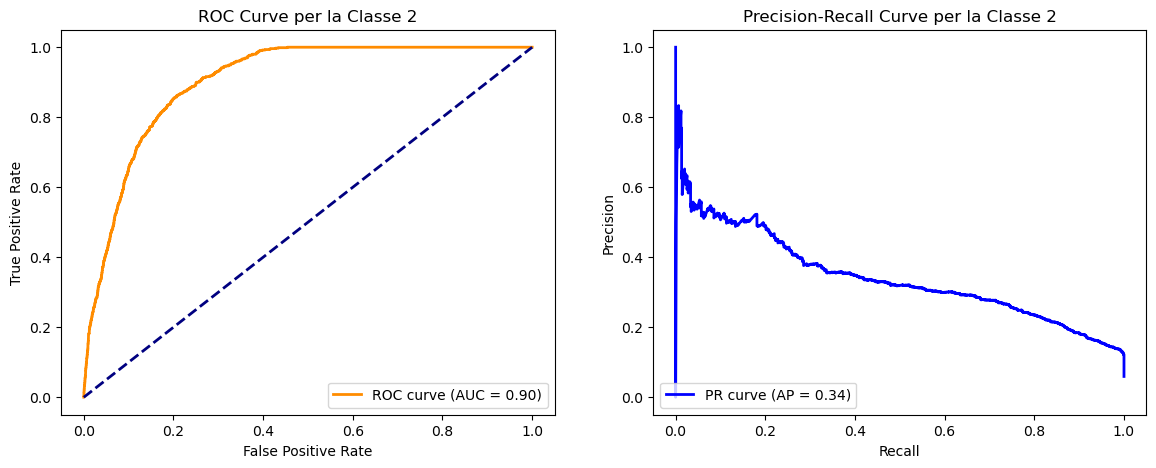

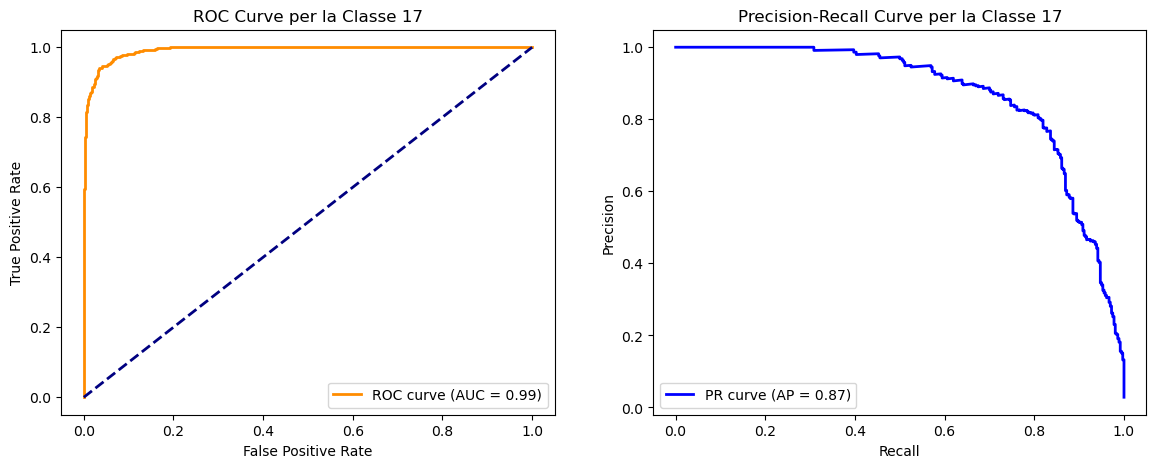


--- Evaluating EfficientNet_v2_s ---


Extracting Features:   0%|          | 0/53 [00:00<?, ?it/s]

Initialized gallery with shape: torch.Size([43, 1000])
Gallery created with 43 classes and 43 features per class.


Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

Classification Report for EfficientNet_v2_s:
              precision    recall  f1-score   support

           0       0.04      0.20      0.07        60
           1       0.52      0.44      0.48       720
           2       0.37      0.24      0.29       750
           3       0.33      0.09      0.14       450
           4       0.31      0.49      0.38       660
           5       0.29      0.19      0.23       630
           6       0.23      0.88      0.37       150
           7       0.50      0.60      0.54       450
           8       0.23      0.20      0.22       450
           9       0.77      0.59      0.67       480
          10       0.73      0.35      0.47       660
          11       0.66      0.23      0.34       420
          12       0.97      0.87      0.92       690
          13       0.95      0.87      0.91       720
          14       0.96      0.73      0.83       270
          15       0.88      0.84      0.86       210
          16       0.76      0.71   

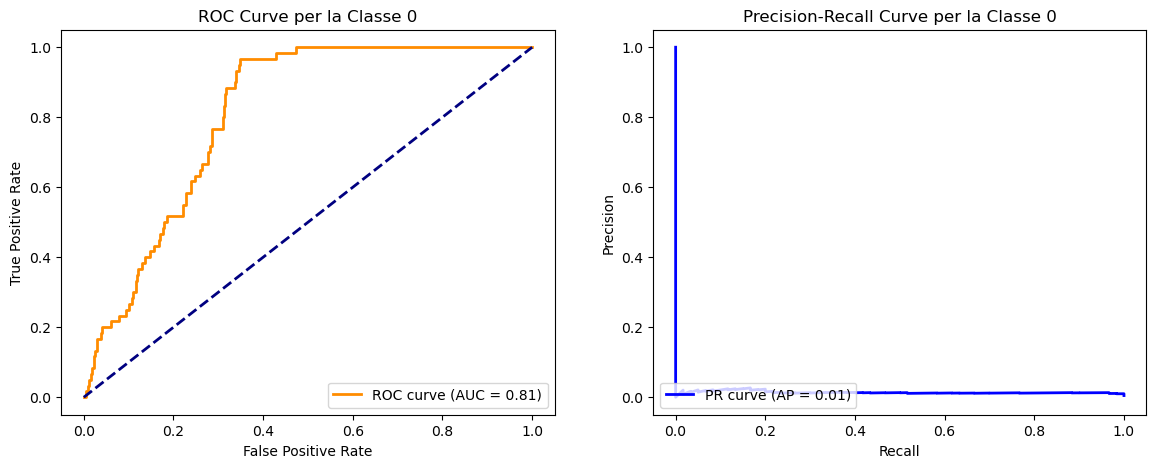

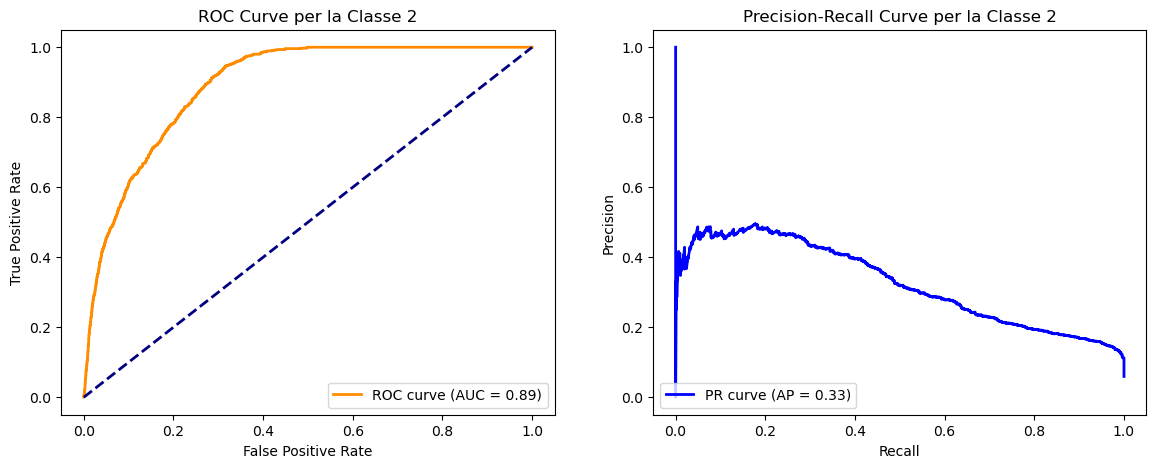

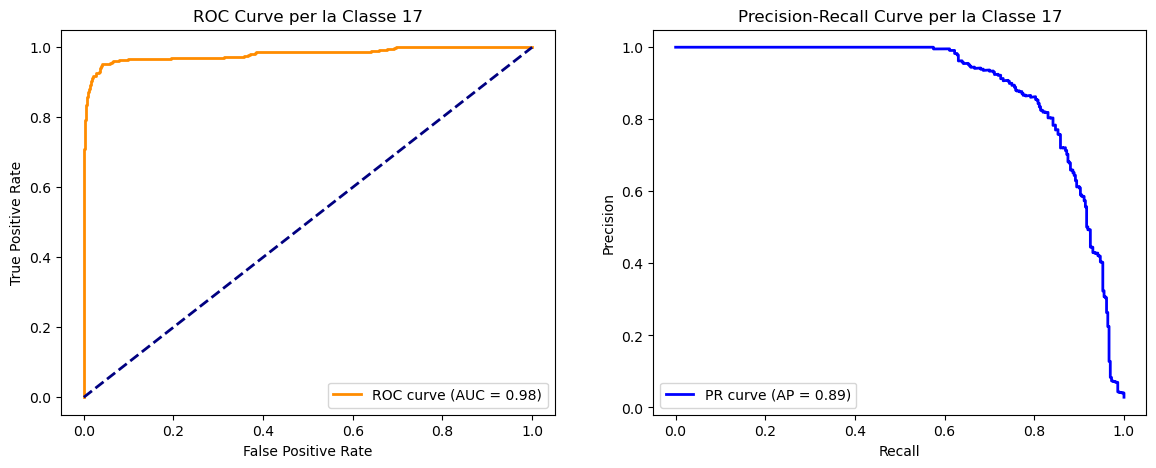


--- Evaluating resnet50 ---


Extracting Features:   0%|          | 0/53 [00:00<?, ?it/s]

Initialized gallery with shape: torch.Size([43, 2048])
Gallery created with 43 classes and 43 features per class.


Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

Classification Report for resnet50:
              precision    recall  f1-score   support

           0       0.02      0.17      0.04        60
           1       0.45      0.39      0.42       720
           2       0.40      0.30      0.34       750
           3       0.30      0.11      0.16       450
           4       0.51      0.34      0.41       660
           5       0.31      0.31      0.31       630
           6       0.49      0.99      0.66       150
           7       0.36      0.30      0.33       450
           8       0.11      0.17      0.14       450
           9       0.41      0.52      0.46       480
          10       0.53      0.44      0.48       660
          11       0.63      0.16      0.25       420
          12       0.94      0.92      0.93       690
          13       0.93      0.84      0.88       720
          14       0.87      0.73      0.79       270
          15       0.73      0.95      0.83       210
          16       0.68      0.71      0.69  

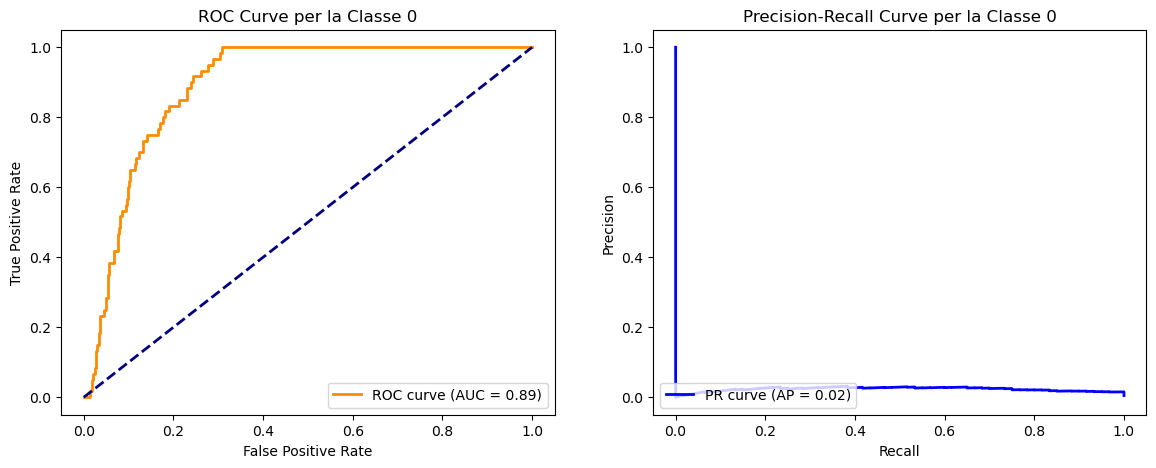

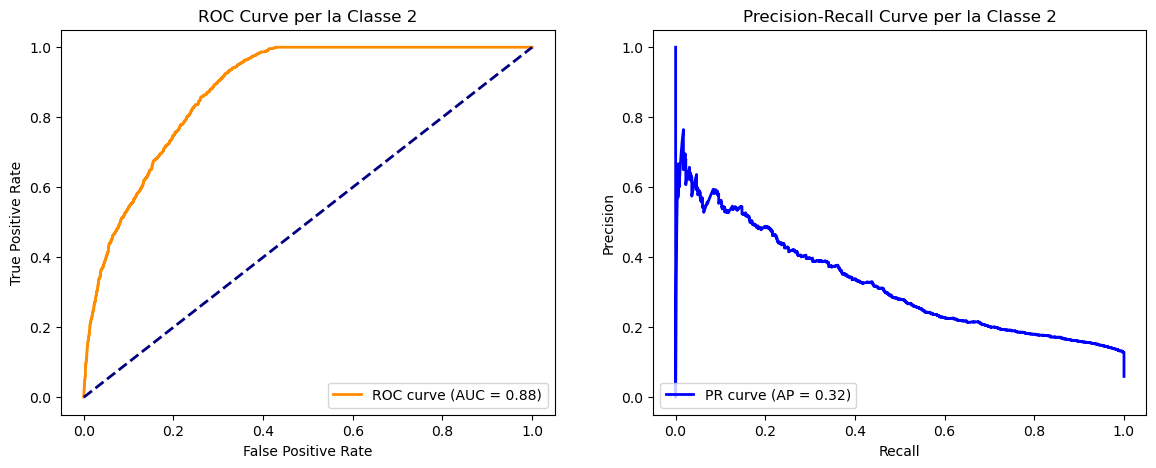

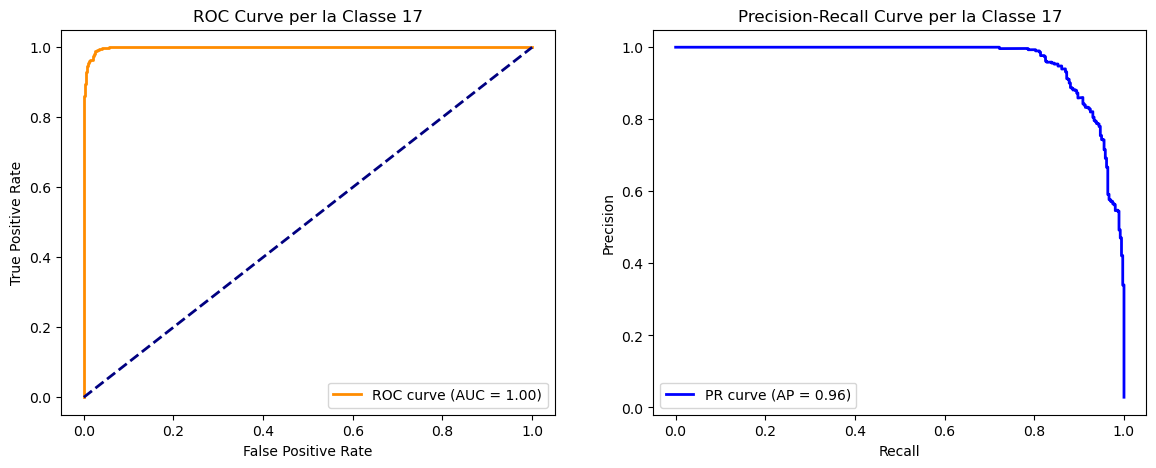

In [13]:
backbones = ['resnext50_32x4d', 'DenseNet121', 'EfficientNet_v2_s', 'resnet50'] 
models = []

for backbone_name in backbones:
     print(f'\n--- Evaluating {backbone_name} ---')
     backbone = get_model(backbone_name, weights = 'DEFAULT')
     backbone.fc = nn.Identity()
     backbone = backbone.to(device)
     
     NMC = NearestNeighborClassifier(backbone, device)
     NMC.fit(dl_train)
     
     predictions, y_scores, test_labels = NMC.evaluate(dl_test)
     
     report = classification_report(test_labels, predictions, zero_division=0)
     print(f'Classification Report for {backbone_name}:')
     print(report)
     
     class_to_plot = [0, 2, 17]  # scelte delle classi sulla base del numero di campioni
     for class_idx in class_to_plot:
          Y_true_bin = label_binarize(test_labels, classes=np.arange(43))
          
          plot_multiclass_curves(Y_true_bin, y_scores, class_to_plot=class_idx)
     
     models.append(NMC)
    

In [33]:
class MetaClassifier(nn.Module):
    def __init__(self, n_models=3, n_classes=43):
        super().__init__()
        input_dim = n_models * n_classes
        
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, n_classes)
        )
        
    def forward(self, x):
        return self.net(x)
    

def get_meta_features(dataloader, models_list):
    scores_per_model = []
    labels_ref = None

    for nmc in tqdm(models_list, desc="Extracting NMC scores for Meta-Classifier"):
        nmc.backbone.eval()
        preds, scores, labels = nmc.evaluate(dataloader)
        # scores: [N, num_classes]
        scores_per_model.append(scores)

        if labels_ref is None:
            labels_ref = labels
        else:
            if labels_ref.shape[0] != labels.shape[0]:
                raise ValueError("Label length mismatch between model evaluations")

    combined = torch.cat(scores_per_model, dim=1)  # [N, n_models * num_classes]
    return combined, labels_ref

def train_meta_model(meta_model, X_train, y_train, epochs=30, batch_size=512, lr = 0.001, weight_decay=1e-4):
    meta_model.train()
    optimizer = torch.optim.Adam(meta_model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    
    train_ds = torch.utils.data.TensorDataset(X_train, y_train)
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4, prefetch_factor=2, persistent_workers=True)
    
    for epoch in range(epochs):
        total_loss = 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(next(meta_model.parameters()).device), batch_y.to(next(meta_model.parameters()).device)
            
            preds = meta_model(batch_x) 
            loss = criterion(preds, batch_y)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(train_loader):.4f}")
        scheduler.step()
        if (epoch+1) % 10 == 0:
            print(f"Learning rate after epoch {epoch+1}: {scheduler.get_last_lr()[0]:.6f}")

def evaluate_meta_model(meta_model, X_test, y_test):
    meta_model.eval()
    with torch.no_grad():
        X_test = X_test.to(next(meta_model.parameters()).device)
        outputs = meta_model(X_test)
        predictions = torch.argmax(outputs, dim=1).cpu().numpy()
        labels = y_test.numpy()
        
    return predictions, outputs, labels


In [20]:
print("\n--- Extracting meta-features for training sets ---")
X_train_meta, y_train_meta = get_meta_features(dl_train, models)
print(f'Meta-features for training set extracted with shape: {X_train_meta.shape} and labels shape: {y_train_meta.shape}')

print("\n--- Extracting meta-features for test sets ---")
X_test_meta, y_test_meta = get_meta_features(dl_test, models)
print(f'Meta-features for test set extracted with shape: {X_test_meta.shape} and labels shape: {y_test_meta.shape}')


--- Extracting meta-features for training sets ---


Extracting NMC scores for Meta-Classifier:   0%|          | 0/4 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/53 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/53 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/53 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

Meta-features for test set extracted with shape: torch.Size([12630, 172]) and labels shape: torch.Size([12630])


In [40]:
meta_classifier = MetaClassifier(n_models=len(models))
train_meta_model(meta_classifier, X_train_meta, y_train_meta, epochs=30, batch_size=128, lr=1e-2)
y_pred, sim,  y_true = evaluate_meta_model(meta_classifier, X_test_meta, y_test_meta)

Epoch 1/30 - Loss: 1.9510
Epoch 2/30 - Loss: 1.5061
Epoch 3/30 - Loss: 1.4225
Epoch 4/30 - Loss: 1.3526
Epoch 5/30 - Loss: 1.3097
Epoch 6/30 - Loss: 1.2727
Epoch 7/30 - Loss: 1.2274
Epoch 8/30 - Loss: 1.1893
Epoch 9/30 - Loss: 1.1561
Epoch 10/30 - Loss: 1.1239
Learning rate after epoch 10: 0.007500
Epoch 11/30 - Loss: 1.0925
Epoch 12/30 - Loss: 1.0597
Epoch 13/30 - Loss: 1.0257
Epoch 14/30 - Loss: 0.9995
Epoch 15/30 - Loss: 0.9666
Epoch 16/30 - Loss: 0.9431
Epoch 17/30 - Loss: 0.9074
Epoch 18/30 - Loss: 0.8816
Epoch 19/30 - Loss: 0.8544
Epoch 20/30 - Loss: 0.8304
Learning rate after epoch 20: 0.002500
Epoch 21/30 - Loss: 0.8104
Epoch 22/30 - Loss: 0.7881
Epoch 23/30 - Loss: 0.7691
Epoch 24/30 - Loss: 0.7502
Epoch 25/30 - Loss: 0.7357
Epoch 26/30 - Loss: 0.7196
Epoch 27/30 - Loss: 0.7192
Epoch 28/30 - Loss: 0.7124
Epoch 29/30 - Loss: 0.7066
Epoch 30/30 - Loss: 0.7083
Learning rate after epoch 30: 0.000000


              precision    recall  f1-score   support

           0       0.00      0.00      0.00        60
           1       0.51      0.47      0.49       720
           2       0.40      0.45      0.43       750
           3       0.22      0.19      0.20       450
           4       0.42      0.44      0.43       660
           5       0.41      0.43      0.42       630
           6       0.67      0.95      0.79       150
           7       0.44      0.32      0.37       450
           8       0.15      0.16      0.16       450
           9       0.53      0.40      0.45       480
          10       0.50      0.72      0.59       660
          11       0.41      0.41      0.41       420
          12       0.91      0.88      0.90       690
          13       0.92      0.89      0.90       720
          14       0.90      0.76      0.82       270
          15       0.71      0.73      0.72       210
          16       0.54      0.19      0.28       150
          17       0.87    

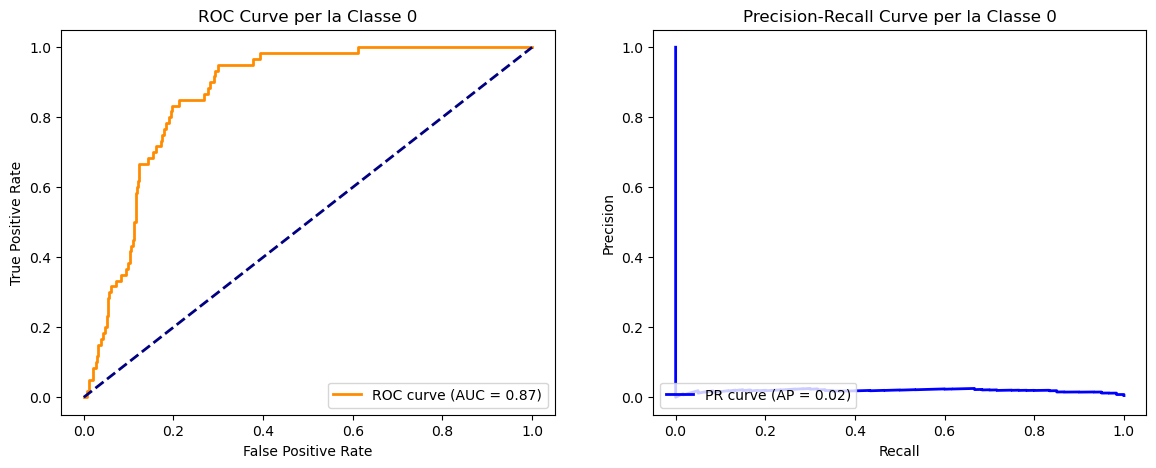

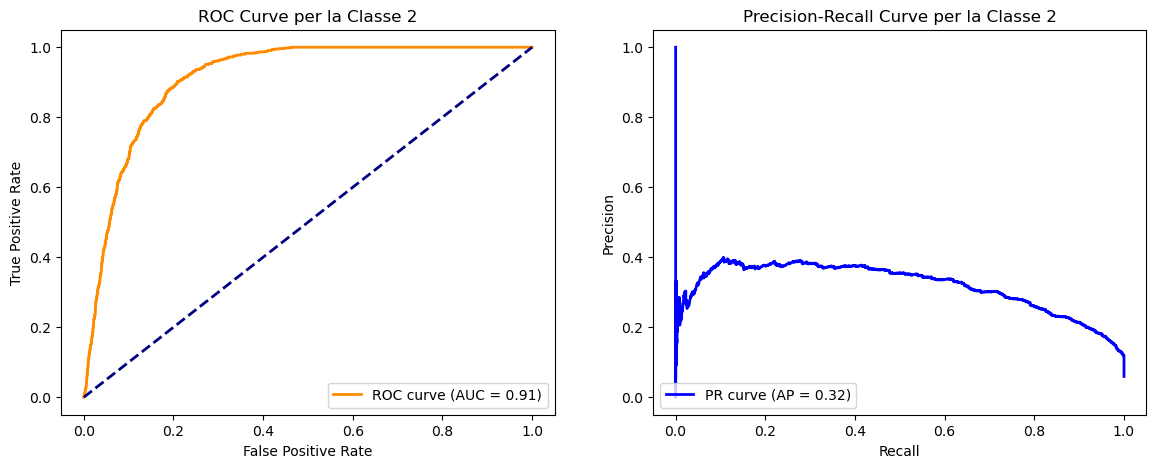

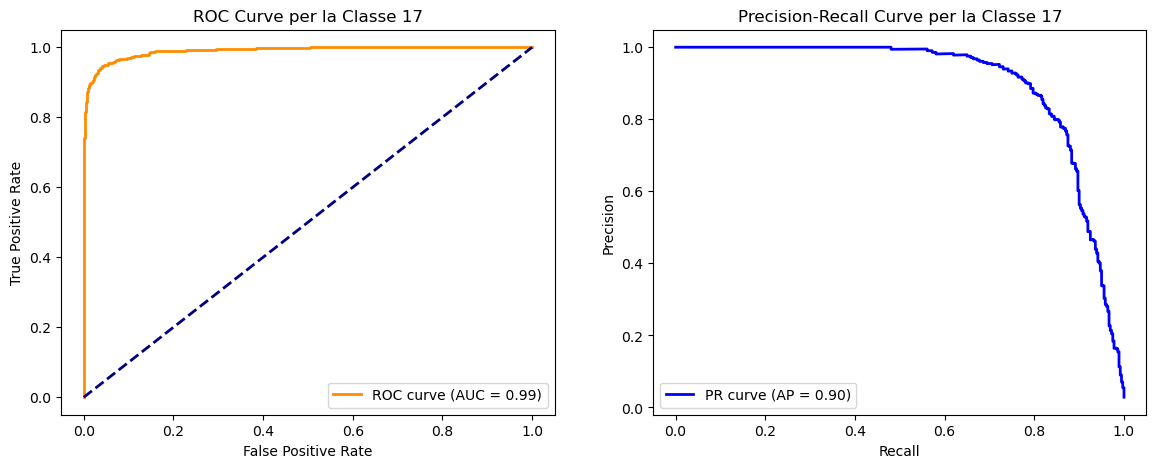

In [41]:
print(classification_report(y_true, y_pred))
for class_idx in [0, 2, 17]:
    Y_true_bin = label_binarize(y_true, classes=np.arange(43))
    plot_multiclass_curves(Y_true_bin, sim.cpu().numpy(), class_to_plot=class_idx)


---
### Exercise 3.3: *Detecting* Traffic Signs (hardest)

In this exercise you will see if you can take your pretrained *classification* backbone and turn it into a *detector*. We will need another dataset for this -- one with *full image frames* instead of cropped sign images. Luckily, this dataset is available on [Hugging Face](https://huggingface.co/datasets/keremberke/german-traffic-sign-detection) (see below for how to access it).

For this exercise, you could:
1. Start from an available Faster-RCNN model from `torchvision` and *replace* the feature extraction backbone with your ResNet fine-tuned on GTRSB.
2. This *stitched-together* network should do an OK-ish job already of detecting at least *some* traffic signs. See how it performs on some of the images from the GTRSB Detection dataset. Implement a simple function to visualize detections superimposed over the original image. Compute some detection metrics (accuracy @ IoU=0.5, for example).
3. If you're feeling ambitious, you could also *fine-tune* the resulting model to improve detection performance.

**NOTE**: The pretrained Faster-RCNN models in `torchvision` are all based on ResNet-50, so this exercise will likely be much less painful if you use a ResNet-50 from the very start.

**Also Note**: To use the **GTRSB Detection Dataset** you should use the `datasets` package from Hugging Face (version 3.X):

     # If using uv.
     uv add datasets==3

or

     # If using Anaconda
     conda install -c conda-forge datasets==3

In [ ]:
from datasets import load_dataset

# Download the full detection dataset from the Hugging Face Hub.
# You will want to spend some time studying the organization of this dataset.
ds = load_dataset("keremberke/german-traffic-sign-detection", name="full")

# Your code here.

RuntimeError: Dataset scripts are no longer supported, but found german-traffic-sign-detection.py

---
---